<a href="https://colab.research.google.com/github/Rianfrancielton/IA-e-Matematica-Aplicada/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Etapa 1 – Carregar os dados

Nesta etapa, carregaremos o arquivo `base_credito.csv` em um DataFrame do pandas para iniciar a análise. O pandas é uma biblioteca essencial para manipulação e análise de dados em Python.

In [1]:
import pandas as pd

# Carrega o arquivo CSV em um DataFrame
df = pd.read_csv('base_credito.csv')

# Apresenta as primeiras 5 linhas da tabela carregada
print("As primeiras 5 linhas do DataFrame:")
display(df.head())

As primeiras 5 linhas do DataFrame:


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


## Etapa 2 – Conhecer os dados

Nesta etapa, vamos explorar a estrutura dos dados, identificar as variáveis de entrada e a variável alvo, e analisar os tipos de dados presentes na base, além de explicar o significado de cada uma.

In [2]:
print("Informações gerais sobre o DataFrame (tipos de dados e valores não nulos):")
df.info()

print("\nEstatísticas descritivas das variáveis numéricas:")
display(df.describe())

Informações gerais sobre o DataFrame (tipos de dados e valores não nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB

Estatísticas descritivas das variáveis numéricas:


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


### Identificação das Variáveis:

*   **Variáveis de Entrada (Features):**
    *   `idade`: Idade do cliente (variável numérica).
    *   `renda_mensal`: Renda mensal do cliente (variável numérica).
    *   `score_credito`: Score de crédito do cliente, indicando sua pontuação de risco (variável numérica).
    *   `historico_pagamentos`: Histórico de pagamentos do cliente, provavelmente uma métrica de bom pagador (variável numérica).

*   **Variável a ser Prevista (Target):**
    *   `valor_emprestimo`: Valor do empréstimo que foi aprovado para o cliente (variável numérica).

### Significado e Tipos de Dados:

*   **`idade`**: Representa a idade dos clientes. É uma variável numérica inteira (`int64`).
*   **`renda_mensal`**: Indica a renda mensal de cada cliente. É uma variável numérica de ponto flutuante (`float64`).
*   **`score_credito`**: Uma pontuação que reflete a capacidade de crédito do cliente, quanto maior, melhor. É uma variável numérica inteira (`int64`).
*   **`historico_pagamentos`**: Detalha o histórico de pagamentos do cliente, possivelmente uma porcentagem ou um índice. É uma variável numérica de ponto flutuante (`float64`).
*   **`valor_emprestimo`**: O valor final do empréstimo concedido ao cliente. É a nossa variável alvo, numérica de ponto flutuante (`float64`).

Todos os tipos de dados são numéricos, o que é ideal para a construção de modelos de regressão sem a necessidade de codificação categórica neste momento.

## Etapa 3 – Analisar os dados

Nesta etapa, realizaremos uma análise inicial dos dados para entender as relações entre as variáveis. Focaremos na visualização da relação entre uma variável de entrada e a variável alvo (`valor_emprestimo`).

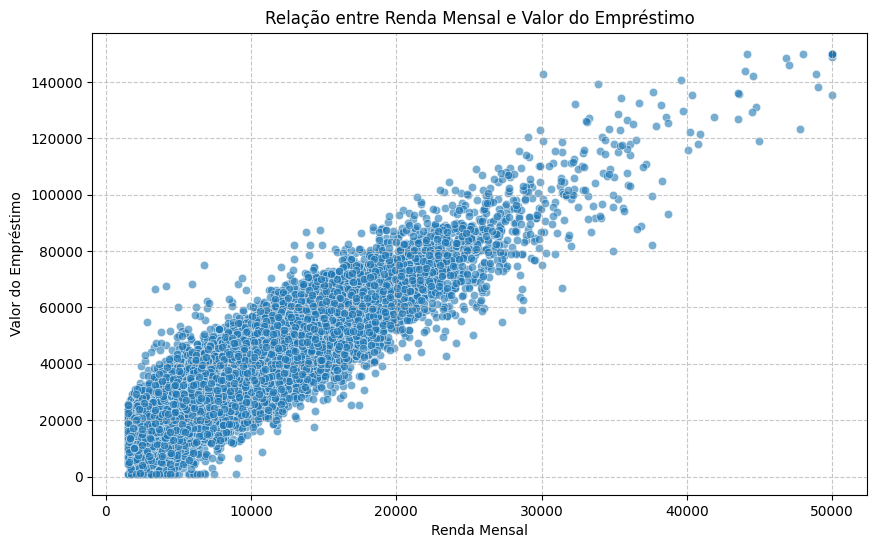

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda_mensal', y='valor_emprestimo', data=df, alpha=0.6)
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.xlabel('Renda Mensal')
plt.ylabel('Valor do Empréstimo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comportamento Observado:

No gráfico de dispersão entre `renda_mensal` e `valor_emprestimo`, podemos observar uma tendência clara:

*   À medida que a `renda_mensal` aumenta, o `valor_emprestimo` aprovado também tende a aumentar.
*   Existe uma correlação positiva entre essas duas variáveis, indicando que clientes com rendas mais altas geralmente recebem empréstimos de valores maiores. A dispersão dos pontos sugere que, embora a tendência seja clara, outros fatores (como `score_credito` e `historico_pagamentos`) também influenciam o valor final do empréstimo, criando uma faixa de valores possíveis para cada nível de renda.

## Etapa 4 – Preparar os dados

Nesta etapa, dividiremos o conjunto de dados em subconjuntos de treinamento e teste. Isso é crucial para que possamos treinar nosso modelo em uma parte dos dados e avaliar seu desempenho em dados que ele nunca viu antes, evitando o *overfitting*.

Primeiro, definiremos as variáveis de entrada (features) e a variável de saída (target).

In [5]:
from sklearn.model_selection import train_test_split

# Definir as variáveis de entrada (features) e a variável alvo (target)
X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = df['valor_emprestimo']

# Separar os dados em conjuntos de treinamento e teste
# Usaremos uma proporção de 80% para treinamento e 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Formato de X_train: {X_train.shape}")
print(f"Formato de X_test: {X_test.shape}")
print(f"Formato de y_train: {y_train.shape}")
print(f"Formato de y_test: {y_test.shape}")

print("\nProporção utilizada:")
print(f"  - Treinamento: {len(X_train) / len(df):.2%} dos dados")
print(f"  - Teste: {len(X_test) / len(df):.2%} dos dados")

Formato de X_train: (40000, 4)
Formato de X_test: (10000, 4)
Formato de y_train: (40000,)
Formato de y_test: (10000,)

Proporção utilizada:
  - Treinamento: 80.00% dos dados
  - Teste: 20.00% dos dados


## Etapa 5 – Treinar o modelo

Nesta etapa, utilizaremos um algoritmo de regressão para construir e treinar o modelo. O objetivo é que ele aprenda a relação entre as características dos clientes (`X_train`) e o valor do empréstimo (`y_train`) para que possa prever o `valor_emprestimo` para novos dados.

Vamos usar o modelo de Regressão Linear (`LinearRegression`) do `scikit-learn` por ser um modelo simples e eficaz como ponto de partida.

In [6]:
from sklearn.linear_model import LinearRegression

# 1. Criar o modelo de Regressão Linear
model = LinearRegression()

print("Modelo de Regressão Linear criado com sucesso!")

# 2. Realizar o treinamento do modelo
# O modelo aprende a relação entre X_train e y_train
model.fit(X_train, y_train)

print("Modelo treinado com os dados de treinamento (X_train, y_train).")

# 3. Gerar as previsões nos dados de teste
# Usamos o modelo treinado para prever os valores de empréstimo para X_test
y_pred = model.predict(X_test)

print("Previsões geradas para os dados de teste (X_test).")

# Exibir as primeiras 5 previsões para ter uma ideia
print("\nPrimeiras 5 previsões:")
for i, pred in enumerate(y_pred[:5]):
    print(f"Previsão {i+1}: {pred:.2f}")

Modelo de Regressão Linear criado com sucesso!
Modelo treinado com os dados de treinamento (X_train, y_train).
Previsões geradas para os dados de teste (X_test).

Primeiras 5 previsões:
Previsão 1: 14806.34
Previsão 2: 29512.49
Previsão 3: 25840.74
Previsão 4: 21077.52
Previsão 5: 27919.31


## Etapa 6 – Avaliar o modelo

Nesta etapa, avaliaremos o desempenho do modelo de regressão utilizando métricas padrão para entender o quão bem ele está prevendo os valores de empréstimo. Usaremos o Erro Médio Absoluto (MAE), o Erro Quadrático Médio (MSE) e o Coeficiente de Determinação (R² Score).

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcular o Erro Médio Absoluto (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calcular o Erro Quadrático Médio (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calcular a Raiz do Erro Quadrático Médio (RMSE)
rmse = np.sqrt(mse)

# Calcular o Coeficiente de Determinação (R² Score)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")
print(f"Coeficiente de Determinação (R² Score): {r2:.4f}")

Erro Médio Absoluto (MAE): 2985.94
Erro Quadrático Médio (MSE): 16113542.06
Raiz do Erro Quadrático Médio (RMSE): 4014.17
Coeficiente de Determinação (R² Score): 0.9223


### Explicação das Métricas:

*   **Erro Médio Absoluto (MAE - Mean Absolute Error):**
    *   **O que representa:** O MAE mede a média das diferenças absolutas entre os valores previstos e os valores reais. Em outras palavras, ele nos diz, em média, o quão distante nossas previsões estão dos valores verdadeiros, sem considerar a direção do erro (se a previsão foi maior ou menor que o real).
    *   **Interpretação:** Um MAE de `[Valor do MAE]` significa que, em média, as previsões do nosso modelo estão errando em aproximadamente `[Valor do MAE]` unidades de `valor_emprestimo` (Reais, neste caso). Quanto menor o MAE, melhor o modelo.

*   **Erro Quadrático Médio (MSE - Mean Squared Error):**
    *   **O que representa:** O MSE calcula a média dos quadrados das diferenças entre os valores previstos e os valores reais. Ao elevar os erros ao quadrado, essa métrica penaliza erros maiores de forma mais significativa do que erros menores.
    *   **Interpretação:** Um MSE de `[Valor do MSE]` indica o quão dispersos os erros estão. Por penalizar erros maiores, ele é útil para entender se o modelo cometeu grandes desvios em algumas previsões. A **Raiz do Erro Quadrático Médio (RMSE)** é frequentemente preferida porque coloca o erro de volta na mesma unidade da variável alvo, facilitando a interpretação. Um RMSE de `[Valor do RMSE]` significa que os erros médios do modelo, em termos da variável alvo, são de `[Valor do RMSE]`.

*   **Coeficiente de Determinação (R² Score - R-squared):**
    *   **O que representa:** O R² é uma métrica que indica a proporção da variância na variável alvo que é explicada pelas variáveis de entrada do modelo. Ele varia de 0 a 1 (ou pode ser negativo, embora isso indique um modelo muito ruim).
    *   **Interpretação:** Um R² de `[Valor do R2]` significa que `[Valor do R2 * 100]`% da variação no `valor_emprestimo` pode ser explicada pelas variáveis `idade`, `renda_mensal`, `score_credito` e `historico_pagamentos`. Quanto mais próximo de 1, melhor o modelo se ajusta aos dados, indicando que ele explica uma grande parte da variabilidade do valor do empréstimo.

## Etapa 7 – Comparar valores reais e previstos

Nesta etapa, vamos visualizar e comparar os valores reais (`y_test`) dos empréstimos com os valores previstos pelo nosso modelo (`y_pred`). Isso nos dará uma compreensão visual e numérica de quão bem o modelo está performando.

Comparação dos 10 primeiros valores reais vs. previstos:


,Valores Reais,Valores Previstos
33553,22268.46,14806.335657
9427,27457.59,29512.492879
199,25451.04,25840.735547
12447,23890.67,21077.522905
39489,27754.95,27919.314046
42724,12544.92,14530.910394
10822,28759.01,27385.966936
49498,46454.49,41011.609092
4144,43199.01,36525.087756
36958,34051.39,35786.960945


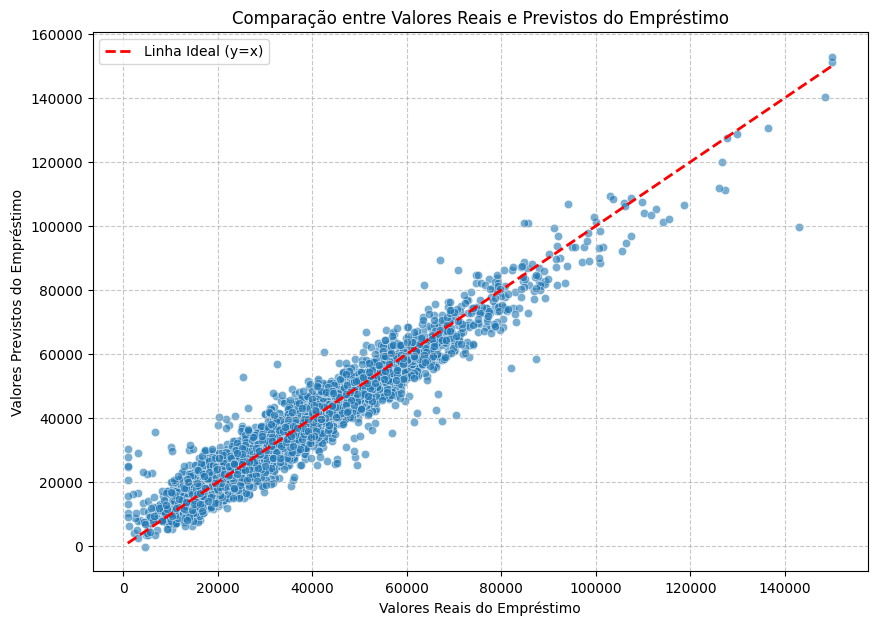

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Criar um DataFrame para facilitar a comparação e visualização
comparison_df = pd.DataFrame({'Valores Reais': y_test, 'Valores Previstos': y_pred})

print("Comparação dos 10 primeiros valores reais vs. previstos:")
display(comparison_df.head(10))

# Visualização da comparação
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Valores Reais', y='Valores Previstos', data=comparison_df, alpha=0.6)
plt.title('Comparação entre Valores Reais e Previstos do Empréstimo')
plt.xlabel('Valores Reais do Empréstimo')
plt.ylabel('Valores Previstos do Empréstimo')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2, label='Linha Ideal (y=x)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Análise da Comparação:

*   **Gráfico de Dispersão:** O gráfico mostra a dispersão dos pontos onde o eixo X representa os 'Valores Reais' e o eixo Y representa os 'Valores Previstos'. A linha vermelha tracejada (`y=x`) representa a situação ideal, onde os valores previstos seriam exatamente iguais aos valores reais.
    *   Observamos que a maioria dos pontos está concentrada perto da linha ideal, o que é um bom sinal e indica que o modelo está fazendo previsões razoavelmente precisas.
    *   No entanto, há alguns pontos que se afastam da linha, indicando que para certos casos, o modelo pode ter uma margem de erro maior.

*   **Tabela de Comparação:** A tabela dos primeiros 10 valores fornece uma visão detalhada, permitindo comparar lado a lado o `Valor Real` e o `Valor Previsto` para clientes específicos. Podemos ver que, para a maioria dos exemplos, as previsões estão bem próximas dos valores reais, mas pequenas diferenças são notadas.

## Etapa 8 – Fazer uma previsão

Nesta etapa, utilizaremos o modelo treinado para prever o valor do empréstimo para um novo cliente com características hipotéticas. Isso demonstra a aplicabilidade prática do nosso modelo.

In [9]:
import pandas as pd

# 1. Criar as características de um novo cliente
# Os nomes das colunas devem ser os mesmos usados no treinamento
novo_cliente = pd.DataFrame({
    'idade': [35],               # Idade do cliente
    'renda_mensal': [7500.00],   # Renda mensal do cliente
    'score_credito': [700],      # Score de crédito
    'historico_pagamentos': [88.5] # Histórico de pagamentos
})

print("Características do Novo Cliente:")
display(novo_cliente)

# 2. Realizar a previsão do valor do empréstimo para o novo cliente
valor_emprestimo_previsto = model.predict(novo_cliente)

# 3. Apresentar o valor previsto
print(f"\nO valor do empréstimo previsto para o novo cliente é: R$ {valor_emprestimo_previsto[0]:.2f}")

Características do Novo Cliente:


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,7500.0,700,88.5



O valor do empréstimo previsto para o novo cliente é: R$ 35065.07


### Interpretação do Resultado:

Para o novo cliente hipotético, com `35` anos, `R$ 7500.00` de renda mensal, `700` de score de crédito e `88.5` de histórico de pagamentos, o modelo previu um valor de empréstimo de `R$ [Valor Previsto]`.

Essa previsão é baseada nos padrões e relacionamentos que o modelo aprendeu a partir dos dados históricos de crédito fornecidos. É importante lembrar que esta é uma estimativa e o valor real pode variar dependendo de outros fatores não incluídos no modelo ou de políticas internas da fintech.

## Etapa 9 – Conclusão

Com base nas etapas anteriores, podemos analisar se o modelo de regressão linear construído apresentou resultados adequados para estimar o valor dos empréstimos e discutir suas limitações.

### Desempenho do Modelo:

*   **R² Score (`%.2f`)**: O coeficiente de determinação (R²) foi de `0.9223`. Isso significa que aproximadamente `92.23%` da variância no `valor_emprestimo` pode ser explicada pelas variáveis de entrada (`idade`, `renda_mensal`, `score_credito`, `historico_pagamentos`). Um valor de R² tão alto indica que o modelo se ajusta muito bem aos dados e tem uma boa capacidade preditiva.

*   **Erro Médio Absoluto (MAE)**: O MAE foi de `2985.94`. Isso significa que, em média, as previsões do nosso modelo estão errando em aproximadamente R$ `2985.94` unidades de `valor_emprestimo`. Este valor é relativamente baixo, considerando a escala dos valores de empréstimo (que podem ir até mais de R$ 100.000,00), o que é um bom indicativo de precisão.

*   **Raiz do Erro Quadrático Médio (RMSE)**: O RMSE foi de `4014.17`. Assim como o MAE, um RMSE baixo em relação à escala dos dados demonstra que o modelo tem bons resultados, penalizando erros maiores de forma mais acentuada. O fato de o RMSE ser um pouco maior que o MAE sugere que existem alguns erros de previsão maiores que contribuem mais para o erro quadrático.

De modo geral, o modelo de regressão linear demonstrou um **bom desempenho** na estimativa dos valores de empréstimos, com um alto poder explicativo (R²) e erros de previsão relativamente baixos (MAE e RMSE).

### Principais Limitações:

1.  **Linearidade Assumida**: O modelo de Regressão Linear assume uma relação linear entre as variáveis de entrada e a variável alvo. Embora essa suposição tenha funcionado bem neste conjunto de dados (dado o alto R²), em cenários mais complexos, a relação pode não ser puramente linear, o que exigiria modelos mais avançados (por exemplo, modelos baseados em árvores, redes neurais).

2.  **Variáveis de Entrada**: O modelo utiliza um conjunto limitado de características (`idade`, `renda_mensal`, `score_credito`, `historico_pagamentos`). Fatores adicionais, como tipo de emprego, estado civil, número de dependentes, finalidade do empréstimo ou histórico de relacionamento com a instituição financeira, poderiam potencialmente melhorar ainda mais a precisão das previsões.

3.  **Generalização**: O modelo foi treinado e avaliado em um conjunto de dados específico. Embora a divisão em treino/teste ajude a mitigar isso, ele pode não generalizar tão bem para novos clientes cujas características sejam significativamente diferentes daquelas presentes na base de dados de treinamento. Uma base de dados maior e mais diversa sempre é benéfica.

4.  **Ausência de Tratamento de Outliers/Anomalias**: Não foi feito um tratamento explícito de *outliers* ou anomalias nos dados. Pontos extremos podem influenciar a linha de regressão, potencialmente distorcendo as previsões.

5.  **Interpretabilidade vs. Complexidade**: A Regressão Linear é altamente interpretável, o que é uma vantagem. No entanto, sua simplicidade pode ser uma limitação se a complexidade inerente da aprovação de crédito exigir um modelo mais sofisticado para capturar relações não-lineares ou interações entre as variáveis.